# Task 4: Feature Selection

## Libraries

In [1]:
DATA_PATH = '../data/students_dataset.csv'
##########################
import random, os, warnings, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
##########################
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
warnings.filterwarnings('ignore')
##########################
sys.path.insert(0, '../src')
from script import*
##########################
sns.set_theme(style='whitegrid', font_scale=1.1)
os.makedirs('../figures', exist_ok=True)
os.makedirs('../results', exist_ok=True)
##########################
with open('../results/winner.json') as f:
    WINNER = json.load(f)['winner']
print(f'Winner algorithm: {WINNER}')
##########################
# Libratied for instantiating the Winner Estimator
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB

Winner algorithm: LDA


## Loading Data

In [2]:
df_raw = pd.read_csv(DATA_PATH) 
df = df_raw.copy()
df['num'] = (df['num'] > 0).astype(int)  
X = df.drop(columns='num')
y = df['num']
print(f'Dataset shape: {X.shape}')
print(f'Class distribution:\n{y.value_counts()}')

Dataset shape: (242, 13)
Class distribution:
num
0    131
1    111
Name: count, dtype: int64


## Instantiate the Winner Estimator

In [3]:
winner_clf_map = {
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=SEED,verbose=-1, n_jobs=-1, class_weight='balanced'),
    'XGBoost':  XGBClassifier(n_estimators=100, random_state=SEED,eval_metric='logloss', verbosity=0, n_jobs=-1),
    'CatBoost': CatBoostClassifier(iterations=100, random_seed=SEED, verbose=0),
    'RF':       RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1, class_weight='balanced'),
    'LR':       LogisticRegression(penalty='elasticnet', solver='saga',l1_ratio=0.5, max_iter=10000, random_state=SEED),
    'LDA':      LinearDiscriminantAnalysis(),
    'GNB':      GaussianNB(),
}

winner_clf = winner_clf_map[WINNER]
print(f'Using: {WINNER}')

Using: LDA


## Define Hyperparameter Space for the Winner

In [4]:
def lgbm_space(trial):
    return {
        'n_estimators':  trial.suggest_int('n_estimators', 50, 500, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':     trial.suggest_int('max_depth', 3, 10),
        'num_leaves':    trial.suggest_int('num_leaves', 15, 63),
        'reg_alpha':     trial.suggest_float('reg_alpha', 1e-5, 1.0, log=True),
        'reg_lambda':    trial.suggest_float('reg_lambda', 1e-5, 1.0, log=True),
        'class_weight':  'balanced',
        'random_state':  SEED,
        'verbose':      -1,
        'n_jobs':       -1,
    }

def xgb_space(trial):
    return {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 500, step=50),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-5, 1.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-5, 1.0, log=True),
        'eval_metric':      'logloss',
        'verbosity':        0,
        'random_state':     SEED,
        'n_jobs':          -1,
    }

def rf_space(trial):
    return {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 500, step=50),
        'max_depth':        trial.suggest_int('max_depth', 3, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight':     'balanced',
        'random_state':     SEED,
        'n_jobs':          -1,
    }

def catboost_space(trial):
    return {
        'iterations':    trial.suggest_int('iterations', 50, 500, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth':         trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_seed':   SEED,
        'verbose':       0,
    }

def lr_space(trial):
    return {
        'C':        trial.suggest_float('C', 1e-3, 10.0, log=True),
        'l1_ratio': trial.suggest_float('l1_ratio', 0.0, 1.0),
        'max_iter': 10000,
        'penalty':  'elasticnet',
        'solver':   'saga',
        'random_state': SEED,
    }

space_map = {'LightGBM': lgbm_space,'XGBoost':  xgb_space,'RF': rf_space,'CatBoost': catboost_space,'LR': lr_space,'LDA': lambda trial: {},
             'GNB': lambda trial: {'var_smoothing': trial.suggest_float('var_smoothing', 1e-11, 1e-6, log=True)},}

winner_param_space = space_map[WINNER]
print(f'Param space loaded for: {WINNER}')

Param space loaded for: LDA


## rnCV with Feature Selection Enabled



In [ ]:
#Setting `feature_selection=True` 
# Feature selection -->  mutual-information-based filter method. 
rncv_fs = RepeatedNestedCV( estimators=[(WINNER, winner_clf)],param_spaces={WINNER: winner_param_space},
    n_repeats=10, n_outer=5, n_inner=3, n_trials=50, base_seed=SEED,tune=True,
    feature_selection=True, fs_n_features=None,inner_metric='roc_auc',)
rncv_fs.fit(X, y)
print('rnCV with feature selection complete.')

rnCV with feature selection complete.


## Feature Selection Frequency



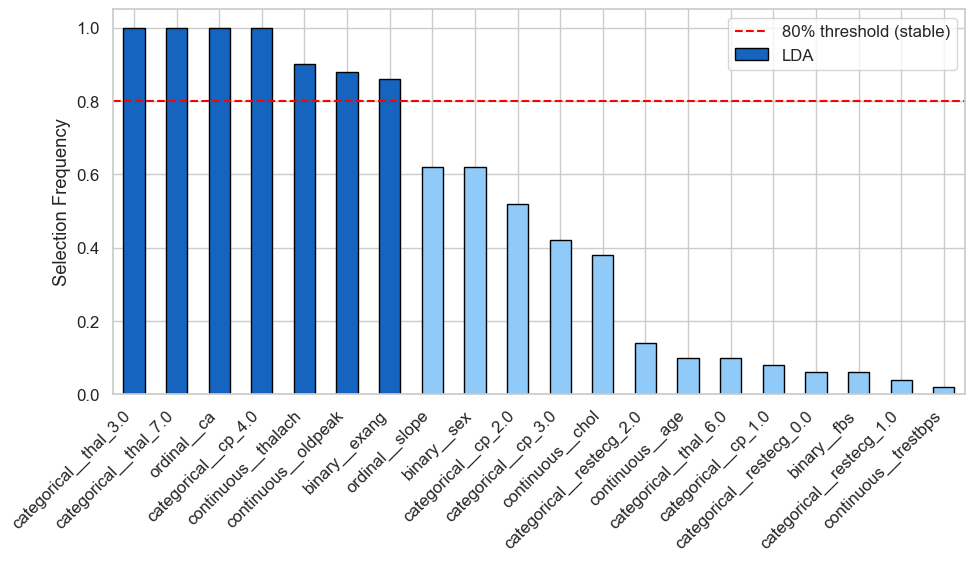

In [ ]:
# Features selected in **>=80%** of the 50 outer folds are considered stable.
# Results affected by one-hot encoder
freq_df = rncv_fs.feature_selection_report()
freq_series = freq_df.loc[WINNER].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#1565C0' if v >= 0.8 else '#90CAF9' for v in freq_series.values]
freq_series.plot(kind='bar', ax=ax, color=colors, edgecolor='black')

ax.axhline(0.8, color='red', linestyle='--', linewidth=1.5, label='80% threshold (stable)')
ax.set_ylabel('Selection Frequency')
ax.set_ylim(0, 1.05)
ax.legend()


plt.suptitle('') 
plt.xticks(rotation=45, ha='right')
plt.savefig('../figures/feature_selection_freq.png', bbox_inches='tight')
plt.show()

#Saving the stable features for later use 
stable_features = freq_series[freq_series >= 0.8].index.tolist()

**Comment:** The first feature selection frequency plot shows the selection stability of the transformed features after preprocessing, but since categorical variables were one-hot encoded, the features appear as separate category-specific dummy variables. 

> Therefore, the selection frequencies were also aggregated back to the original feature level. 

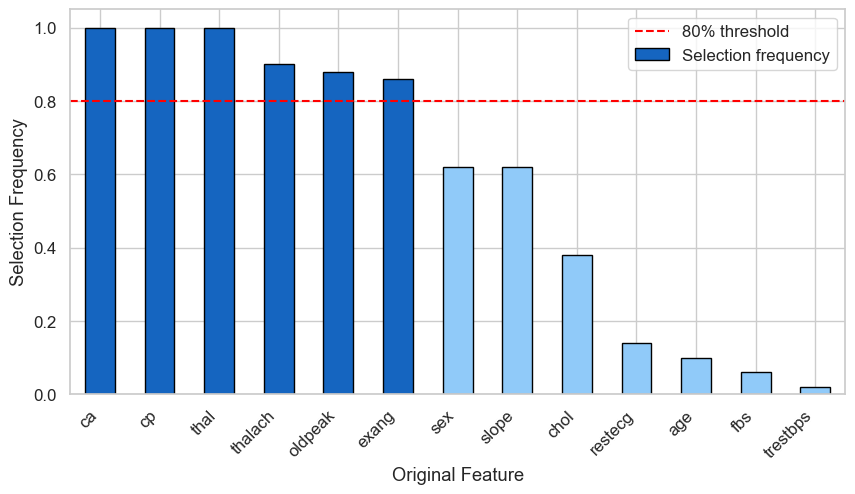

In [11]:
# Convert transformed feature names back to original feature names
def get_original_feature_name(transformed_name):
    name = transformed_name.split("__", 1)[1]
    for cat in categorical_cols:
        if name.startswith(cat + "_"):
            return cat
    return name

freq_original_df = pd.DataFrame({
    "Transformed feature": freq_series.index,
    "Original feature": [get_original_feature_name(f) for f in freq_series.index],
    "Selection frequency": freq_series.values
})

# Aggregate by original feature
original_freq = (freq_original_df
                 .groupby("Original feature")["Selection frequency"]
                 .max()
                 .sort_values(ascending=False))


#Plotting again the results
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#1565C0" if v >= 0.8 else "#90CAF9" for v in original_freq.values]

original_freq.plot( kind="bar", ax=ax,color=colors, edgecolor="black")

ax.axhline( 0.8, color="red", linestyle="--", linewidth=1.5,label="80% threshold")
ax.set_ylabel("Selection Frequency")
ax.set_xlabel("Original Feature")
ax.set_ylim(0, 1.05)
ax.legend()


plt.xticks(rotation=45, ha="right")
plt.savefig("../figures/feature_selection_freq_original_features.png", bbox_inches="tight")
plt.show()

# Stable original features
stable_original_features = original_freq[original_freq >= 0.8].index.tolist()


**Comment:** The variables  `ca`, `cp`, and `thal` were selected in all outer-fold evaluations, while `thalach`, `oldpeak`, and `exang` also exceeded the 80% stability threshold, results that suggest that the predictive information for the LDA model comes mainly from those 6 features, results consistent with the EDA findings, where they showed visible differences between patients with and without heart disease, in contrast to the rest of the features, where the indication of disease was not clear either before.

## Re-run rnCV on Stable Features Only

In [14]:
#Running it only in the winner algorithm
X_stable = X[stable_original_features]
print(f'Stable feature matrix: {X_stable.shape}')

rncv_stable = RepeatedNestedCV( estimators=[(WINNER, winner_clf)],param_spaces={WINNER: winner_param_space},
    n_repeats=10, n_outer=5, n_inner=3,n_trials=50,
    base_seed=SEED, tune=True, feature_selection=False,inner_metric='roc_auc',)

rncv_stable.fit(X_stable, y)
print('rnCV on stable features complete.')

Stable feature matrix: (242, 6)
rnCV on stable features complete.


---

## Performance Comparison

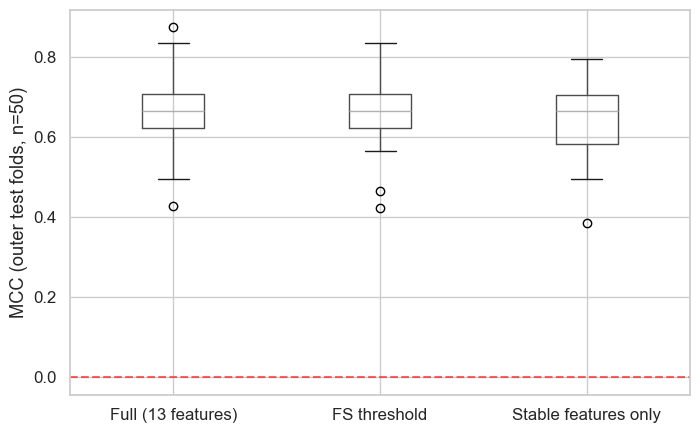

In [15]:
with open('../results/rncv_results.json') as f:
    all_results = json.load(f)

full_mcc   = pd.DataFrame(all_results[WINNER])['MCC'].values
fs_mcc     = rncv_fs.get_fold_results(WINNER)['MCC'].values
stable_mcc = rncv_stable.get_fold_results(WINNER)['MCC'].values

compare_df = pd.DataFrame({'Full (13 features)':   full_mcc,'FS threshold': fs_mcc,'Stable features only': stable_mcc,})

fig, ax = plt.subplots(figsize=(8, 5))
compare_df.boxplot(ax=ax)
ax.axhline(0, color='red', linestyle='--', alpha=0.6)
ax.set_ylabel('MCC (outer test folds, n=50)')

plt.suptitle('') 
plt.savefig('../figures/fs_comparison.png', bbox_inches='tight')
plt.show()

## Full Metric Summary

In [16]:
key_cols = ['MCC_median', 'AUC_median', 'BA_median','F1_median', 'Recall_median', 'Specificity_median']

print(' rnCV with FS:')
display(rncv_fs.summary()[key_cols])

print('rnCV with Stable Features Only:')
display(rncv_stable.summary()[key_cols])

 rnCV with FS:


,MCC_median,AUC_median,BA_median,F1_median,Recall_median,Specificity_median
Estimator,,,,,,
LDA,0.6643,0.8906,0.8297,0.8095,0.7727,0.8846


rnCV with Stable Features Only:


,MCC_median,AUC_median,BA_median,F1_median,Recall_median,Specificity_median
Estimator,,,,,,
LDA,0.6643,0.8834,0.8234,0.8043,0.7727,0.8846


## Saving Stable Features 

In [17]:
with open('../results/stable_original_features.json', 'w') as f:
    json.dump({'stable_original_features': stable_original_features}, f, indent=2)
print(f'Saved: {stable_original_features}')

Saved: ['ca', 'cp', 'thal', 'thalach', 'oldpeak', 'exang']
